### Rank Histogram Analysis for Ensemble Kalman Filter

In [124]:
from diffrax import diffeqsolve, ODETerm,VirtualBrownianTree,MultiTerm,ControlTerm
from jax.scipy.stats import norm, poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [125]:
def rhs(t,state,args):

    sigma,rho,beta = args
    x,y,z = state

    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x*y - beta * z

    return jnp.array([dx,dy,dz])



In [126]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=1e-3,
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts),
            stepsize_controller = diffrax.PIDController(1e-3,1e-3)
        )
  return solution.ys

In [127]:
t_vec = jnp.linspace(0,15,750)

rng_key = jax.random.PRNGKey(0)

noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''

full_state = model(t_vec,jnp.array([[0.0,0.5,0.1]]).T,(10.,28.,8/3))

# Generate noisy observations of the first state component x(t) with additive Gaussian noise ~N(0,1).
last_obs = 500
t_vec_obs = t_vec[:last_obs]
noise_std = 0.5
observations = full_state[:last_obs,0] + noise_std * jax.random.normal(noise_key,shape = full_state[:last_obs,0].shape)

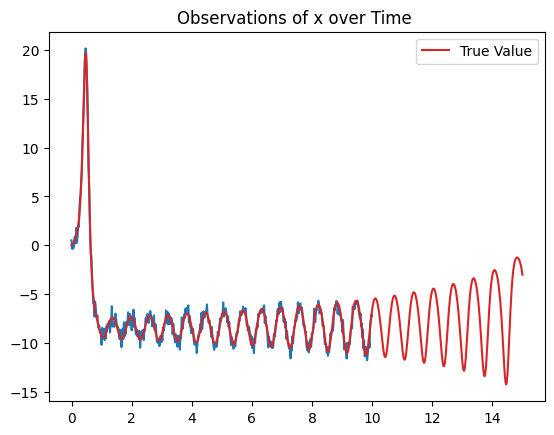

In [128]:
plt.title('Observations of x over Time ')
plt.plot(t_vec_obs,observations)
plt.plot(t_vec,full_state[:,0],label = 'True Value',color = "tab:red",zorder = 100)
plt.legend()
plt.show()

In [129]:
def ensemble_kalman_filter(observations, delta_t, initial_ensemble, key, R_obs):
    def kalman_step(state, i):
        prev_ensemble, prev_key = state
        forecast_ensemble = jax.vmap(model, in_axes=(None, 0, None))(
            jnp.linspace(0, delta_t, 10), prev_ensemble, (10.0, 28.0, 8 / 3)
        )[:, -1, :]

        mean = jnp.mean(forecast_ensemble, axis=0)
        inflation_factor = 1.
        state_perturbation_matrix = (
            1 / jnp.sqrt(len(forecast_ensemble) - 1) * (forecast_ensemble - mean)
        ).squeeze()

        state_perturbation_matrix *= inflation_factor

        obs_mean = mean[0]
        obs_perturbation_matrix = (
            1
            / jnp.sqrt(len(forecast_ensemble) - 1)
            * (forecast_ensemble[:, 0] - obs_mean)
        )

        cross_cov = state_perturbation_matrix.T @ obs_perturbation_matrix

        S = (
            obs_perturbation_matrix.T
            @ obs_perturbation_matrix
        )

        S_inv = jnp.linalg.pinv(S)

        def update_step(member, observation, key):

            perturbed_observation = observation + R_obs * jax.random.normal(
                key
            )

            innovation = perturbed_observation - member[0]
            alpha = S_inv @ jnp.array([innovation])
            member = member + cross_cov @ alpha

            return member

        update_key,curr_key = jax.random.split(prev_key)
        update_keys = jax.random.split(update_key,len(forecast_ensemble))
        update_ensemble = jax.vmap(update_step, in_axes=(0, None, 0))(
            forecast_ensemble, observations[i], update_keys
        )

        return (update_ensemble, curr_key), update_ensemble

    return jax.lax.scan(kalman_step, (initial_ensemble, key), xs = jnp.arange(0,len(observations)))


In [130]:
ensemble_key, rng_key = jax.random.split(rng_key)
num_ensemble_members = 25
init_ensemble = jax.random.multivariate_normal(
    ensemble_key, mean=jnp.zeros(3),cov = 0.1 * jnp.eye(3), shape=(num_ensemble_members)
)[...,jnp.newaxis]

inference_key,rng_key = jax.random.split(rng_key)
_,output = ensemble_kalman_filter(observations, t_vec[1] - t_vec[0],init_ensemble,inference_key,noise_std)


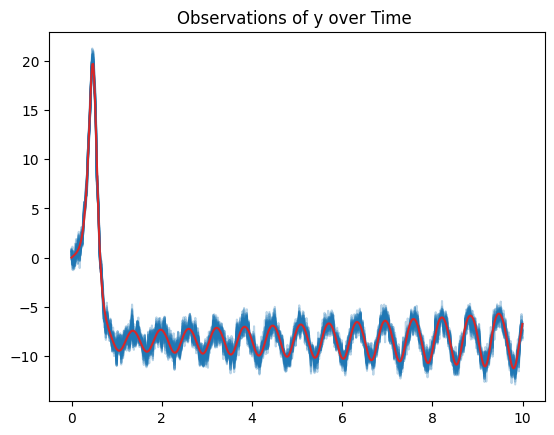

In [131]:
plt.title('Observations of y over Time ')
plt.plot(t_vec_obs,full_state[:last_obs,0],color = 'tab:red',zorder = 100)
plt.plot(t_vec_obs,output[:,:,0].squeeze(),color = 'tab:blue',alpha = 0.3)
plt.show()

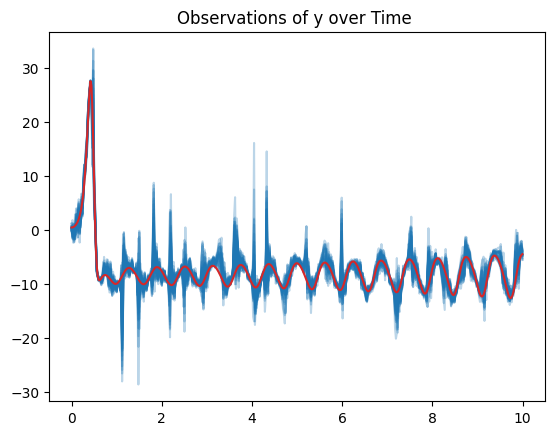

In [132]:
plt.title('Observations of y over Time ')
plt.plot(t_vec_obs,full_state[:last_obs,1],color = 'tab:red',zorder = 100)
plt.plot(t_vec_obs,output[:,:,1].squeeze(),color = 'tab:blue',alpha = 0.3)
plt.show()

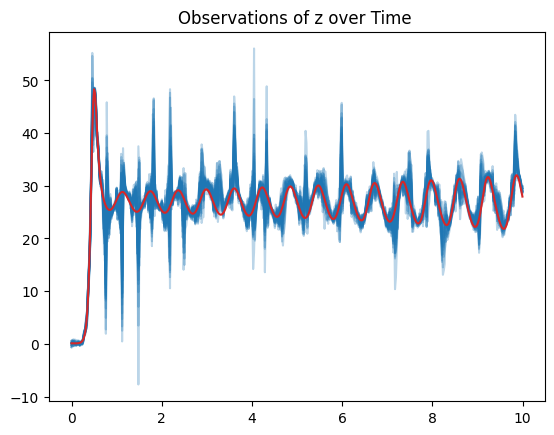

In [133]:
plt.title('Observations of z over Time ')
plt.plot(t_vec_obs,full_state[:last_obs,2],color = 'tab:red',zorder = 100)
plt.plot(t_vec_obs,output[:,:,2].squeeze(),color = 'tab:blue',alpha = 0.3)
plt.show()

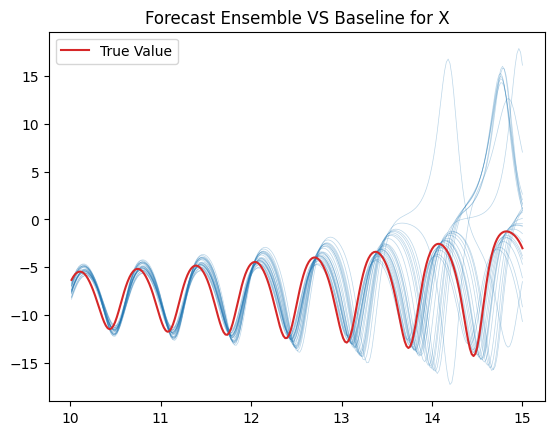

In [134]:
### Forecast 
init_cond = output[-1,:,:,:].squeeze()
forecast = jax.vmap(model,in_axes = (None,0,None))(t_vec[last_obs:],init_cond,(10.,28.,8/3))

plt.title('Forecast Ensemble VS Baseline for X')
plt.plot(t_vec[last_obs:],full_state[last_obs:,0],color = 'tab:red',zorder = 100,label = 'True Value')
plt.plot(t_vec[last_obs:],forecast[:,:,0].T,color = 'tab:blue',alpha = 0.3,lw = 0.5)
plt.legend()
plt.show()

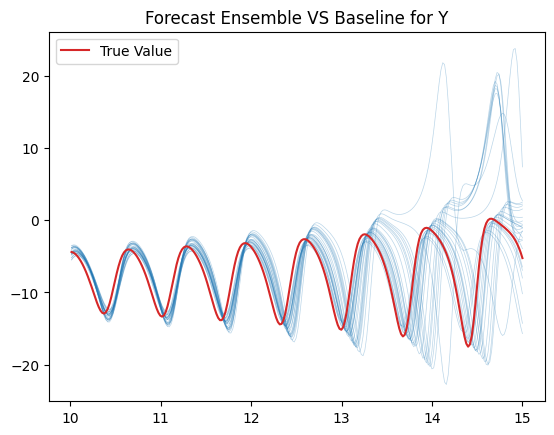

In [135]:
plt.title('Forecast Ensemble VS Baseline for Y')
plt.plot(t_vec[last_obs:],full_state[last_obs:,1],color = 'tab:red',zorder = 100,label = 'True Value')
plt.plot(t_vec[last_obs:],forecast[:,:,1].T,color = 'tab:blue',alpha = 0.3,lw = 0.5)
plt.legend()
plt.show()

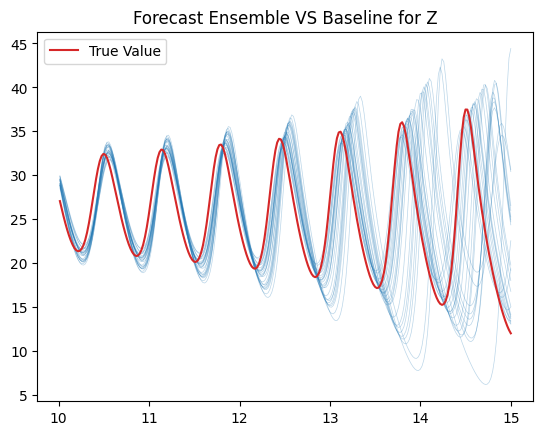

In [136]:
plt.title('Forecast Ensemble VS Baseline for Z')
plt.plot(t_vec[last_obs:],full_state[last_obs:,2],color = 'tab:red',zorder = 100,label = 'True Value')
plt.plot(t_vec[last_obs:],forecast[:,:,2].T,color = 'tab:blue',alpha = 0.3,lw = 0.5)
plt.legend()
plt.show()

(250, 1)
(250, 25)


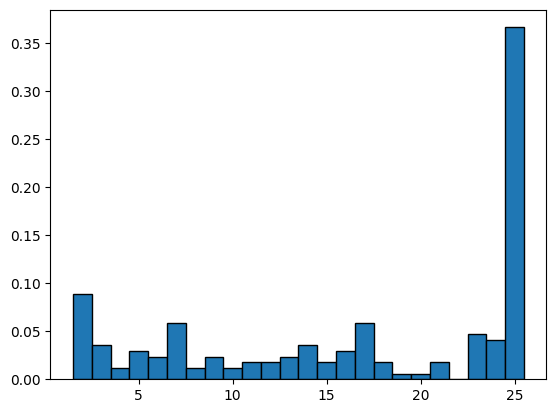

In [ ]:
def get_rank_histogram(truth,ensemble,var): 
    obs = truth[:,var]
    ens = ensemble[:,:,var].squeeze().T

    is_smaller = ens < obs

    ranks = jnp.sum(is_smaller,axis = 1)
    return ranks

lorenz_ranks = get_rank_histogram(full_state[last_obs:],forecast,0)

plt.hist(lorenz_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black',density = True)
plt.show()

In [157]:
'''Baseline Normal Distribution'''

def get_rank_histogram(truth,ensemble): 
    obs = truth
    ens = ensemble

    is_smaller = ens < obs
    ranks = jnp.sum(is_smaller,axis = 0)
    return ranks

rng_key,truth_key = jax.random.split(rng_key)

num_truth_points = 100000
num_ensemble_members = 20
mu = 2.0
sigma = 1.0

V = jax.random.normal(truth_key, shape = (num_truth_points,))
forecast_key, rng_key = jax.random.split(rng_key)
forecast = mu + sigma * jax.random.normal(forecast_key, shape  = (num_ensemble_members, num_truth_points))

norm_ranks = get_rank_histogram(V,forecast)

print(norm_ranks.shape)

(100000,)


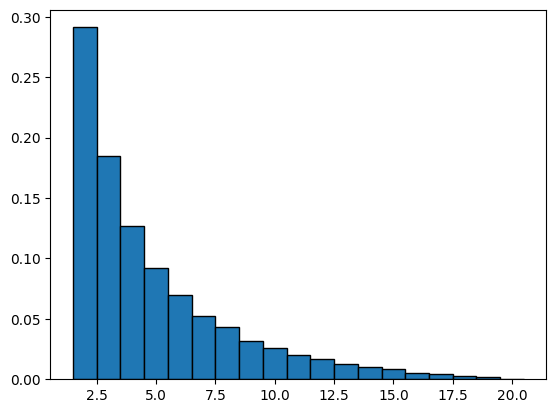

In [158]:
plt.hist(norm_ranks,bins=jnp.arange(num_ensemble_members) + 2 - 0.5, edgecolor='black',density = True)
plt.show()